In [1]:
import math
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 0. Import Datasets:

In [2]:
customers_db = pd.read_csv("data/DM_AIAI_CustomerDB.csv", sep=",", index_col=0)
flights_db = pd.read_csv("data/DM_AIAI_FlightsDB.csv", sep=",")

In [3]:
customers_db.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [4]:
flights_db.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


# 1. Analysis of both table combined:

### 1.1.4. Data inconsistencies:

In [5]:
customer_loyalty = set(customers_db['Loyalty#'].unique())
flight_loyalty = set(flights_db['Loyalty#'].unique())
customers_not_in_flights_set = customer_loyalty.difference(flight_loyalty)
print(customers_not_in_flights_set)
print(f'{len(customers_not_in_flights_set)} customers records not found in the flight database')

{np.int64(100011), np.int64(100012), np.int64(100013), np.int64(100014), np.int64(100015), np.int64(100016), np.int64(100017), np.int64(999987), np.int64(999988), np.int64(999989), np.int64(999990), np.int64(999991), np.int64(999992), np.int64(999993), np.int64(999994), np.int64(999995), np.int64(999996), np.int64(999997), np.int64(999998), np.int64(999999)}
20 customers records not found in the flight database


In [6]:
flights_sum = flights_db.groupby('Loyalty#').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',
    'DollarCostPointsRedeemed': 'sum'
}).reset_index()
customers_detailed = pd.merge(customers_db, flights_sum, on="Loyalty#", how="left")
customers_detailed[customers_detailed["Loyalty#"]==711864]["NumFlights"]

1765    170.8
Name: NumFlights, dtype: float64

### Filling the missing values of newly created columns with 0 and converting data type of some columns

In [7]:
# List of new columns to fill with 0
new_cols = ['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 
            'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']

# Fill NaN values in the new columns with 0
customers_detailed[new_cols] = customers_detailed[new_cols].fillna(0)

# Optional: Convert relevant columns to integer type (e.g., counts and points)
int_cols = ['NumFlights', 'NumFlightsWithCompanions']
customers_detailed[int_cols] = customers_detailed[int_cols].astype(int)

In [8]:
print(customers_detailed[customers_detailed["Loyalty#"] == 711864]["NumFlights"])

1765    170
Name: NumFlights, dtype: int64


### 1.1.5. Feature Engineering between features from each tables:

In [9]:
metric_features = ["Income", "Customer Lifetime Value", "Latitude", "Longitude", "NumFlights", 
                   "NumFlightsWithCompanions", "DistanceKM", "PointsAccumulated", "PointsRedeemed", "DollarCostPointsRedeemed"]

### 1.1.6. Visualizations:

#### 1.1.6.1 Univariate Analysis for newly created features:

##### 1.1.6.1.1. Metric Features:

In [10]:
def plot_histograms_side_by_side(df, cols, bins=30, figsize=(12, 4)):
    
    n = len(cols)
    if n == 0:
        return

    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c]  
        nan_count = s.isna().sum()
        total = len(s)

        ax.hist(s, bins=bins, edgecolor="black")  
        ax.set_title(f"Histogram of {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25)
        ax.text(
            0.99, 0.95,
            f"NaNs: {nan_count/total*100:.2f}%",
            transform=ax.transAxes, ha="right", va="top"
        )

    plt.tight_layout()
    plt.show()


### Graphical interpretation:

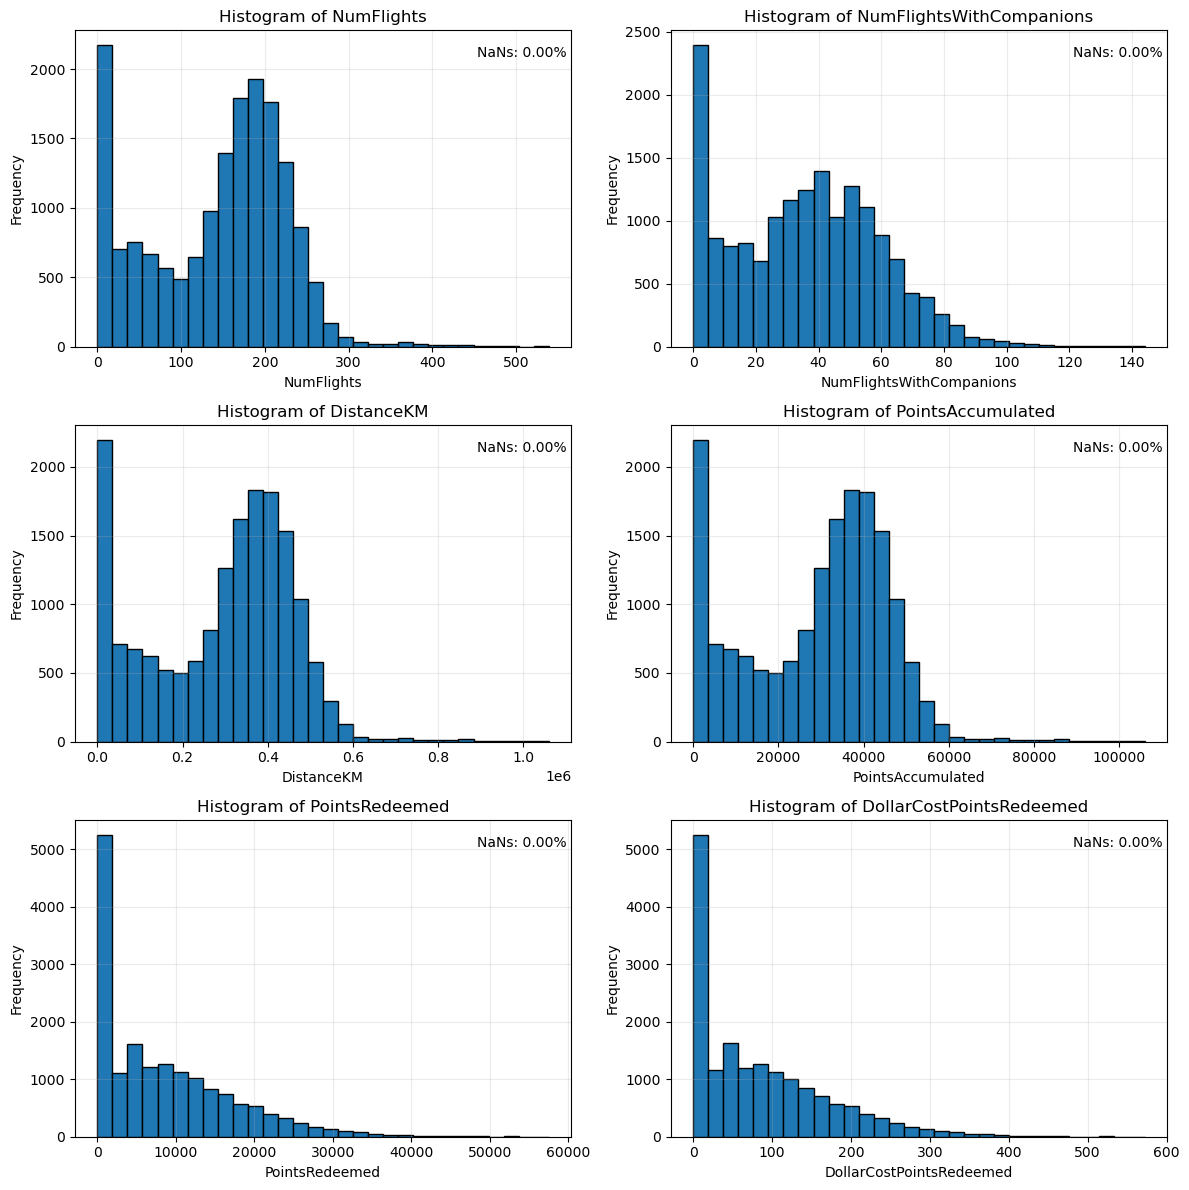

In [11]:
plot_histograms_side_by_side(customers_detailed, new_cols)

##### 1.1.6.1.2. Non-Metric Features:

In [12]:
def plot_bar_chart_top15(
    df: pd.DataFrame,
    cols: list[str],
    ncols: int = 2,
    figsize_per_row: tuple = (12, 4),
    rotate_xticks: int = 30,
):

    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    total_rows = len(df)

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype("string")  
        counts = s.value_counts(dropna=False)    
        counts_plot = counts.iloc[:15]          

        categories = counts_plot.index.tolist()
        values = counts_plot.values

        ax.bar(categories, values, edgecolor="black")
        ax.set_title(f"{col} (Top-15)")
        ax.set_ylabel("Count")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")

        # Annotate percentage:
        for x, v in enumerate(values):
            pct = (v / total_rows * 100) if total_rows else 0
            ax.text(x, v, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

        # Annotate NaNs percentage:
        nan_pct = s.isna().mean() * 100
        ax.text(0.99, 0.95, f"NaNs: {nan_pct:.2f}%", transform=ax.transAxes, ha="right", va="top", fontsize=9)

    # Remove empty axis for odd number of variables:
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


### Graphical interpretation:

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_37022/2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_37022/2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_37022/2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_37022/2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of tick

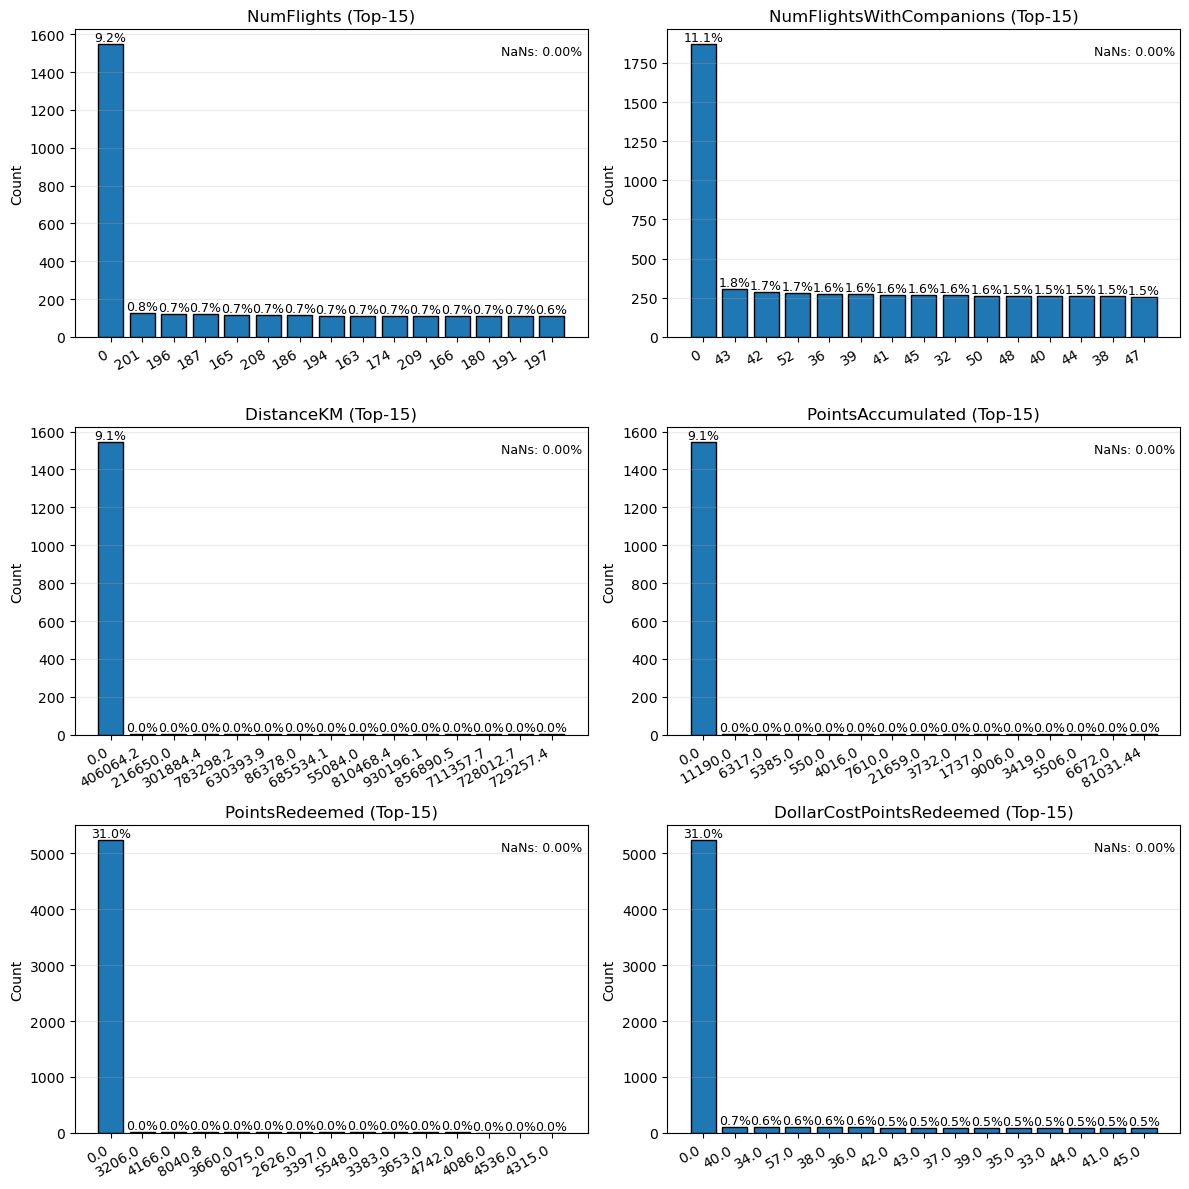

In [13]:
plot_bar_chart_top15(customers_detailed, new_cols)

## Outliers of newly created features:

In [14]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

### Graphical interpretation:

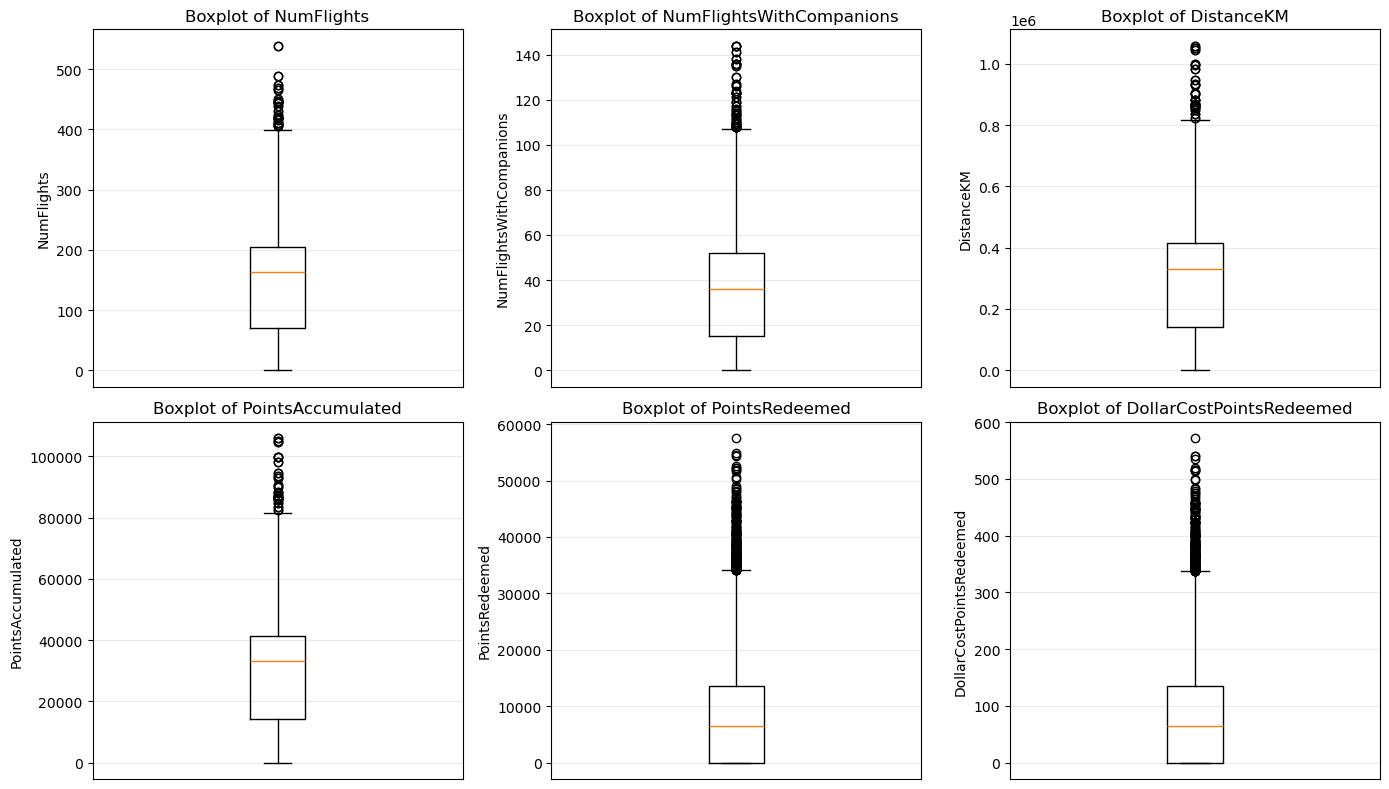

In [15]:
boxplot_grid(customers_detailed, new_cols)

### Multivariate Analysis:

### Numerical x Numerical features:

In [16]:
def plot_pairwise_numeric(df, metric_features, title="Pairwise Relationship of Numerical Variables"):
    # Style and grid:
    sns.set_theme(style="ticks", rc={
        "axes.grid": True,
        "grid.color": ".9",
        "grid.linestyle": "-",
        "axes.spines.right": False,
        "axes.spines.top": False,
    })

    g = sns.pairplot(
        data=df[metric_features],
        diag_kind="hist",
        height=3.2,       
        aspect=1.0,
        corner=False,
        plot_kws=dict(
            s=14,         
            alpha=0.45,   
            linewidth=0.25,
            edgecolor="black",  
            rasterized=True     
        ),
        diag_kws=dict(
            bins=30,
            edgecolor="black",
            linewidth=0.2
        )
    )

    g.fig.suptitle(title, fontsize=18, y=1.02)
    plt.show()
    return g


### Graphical interpretation:

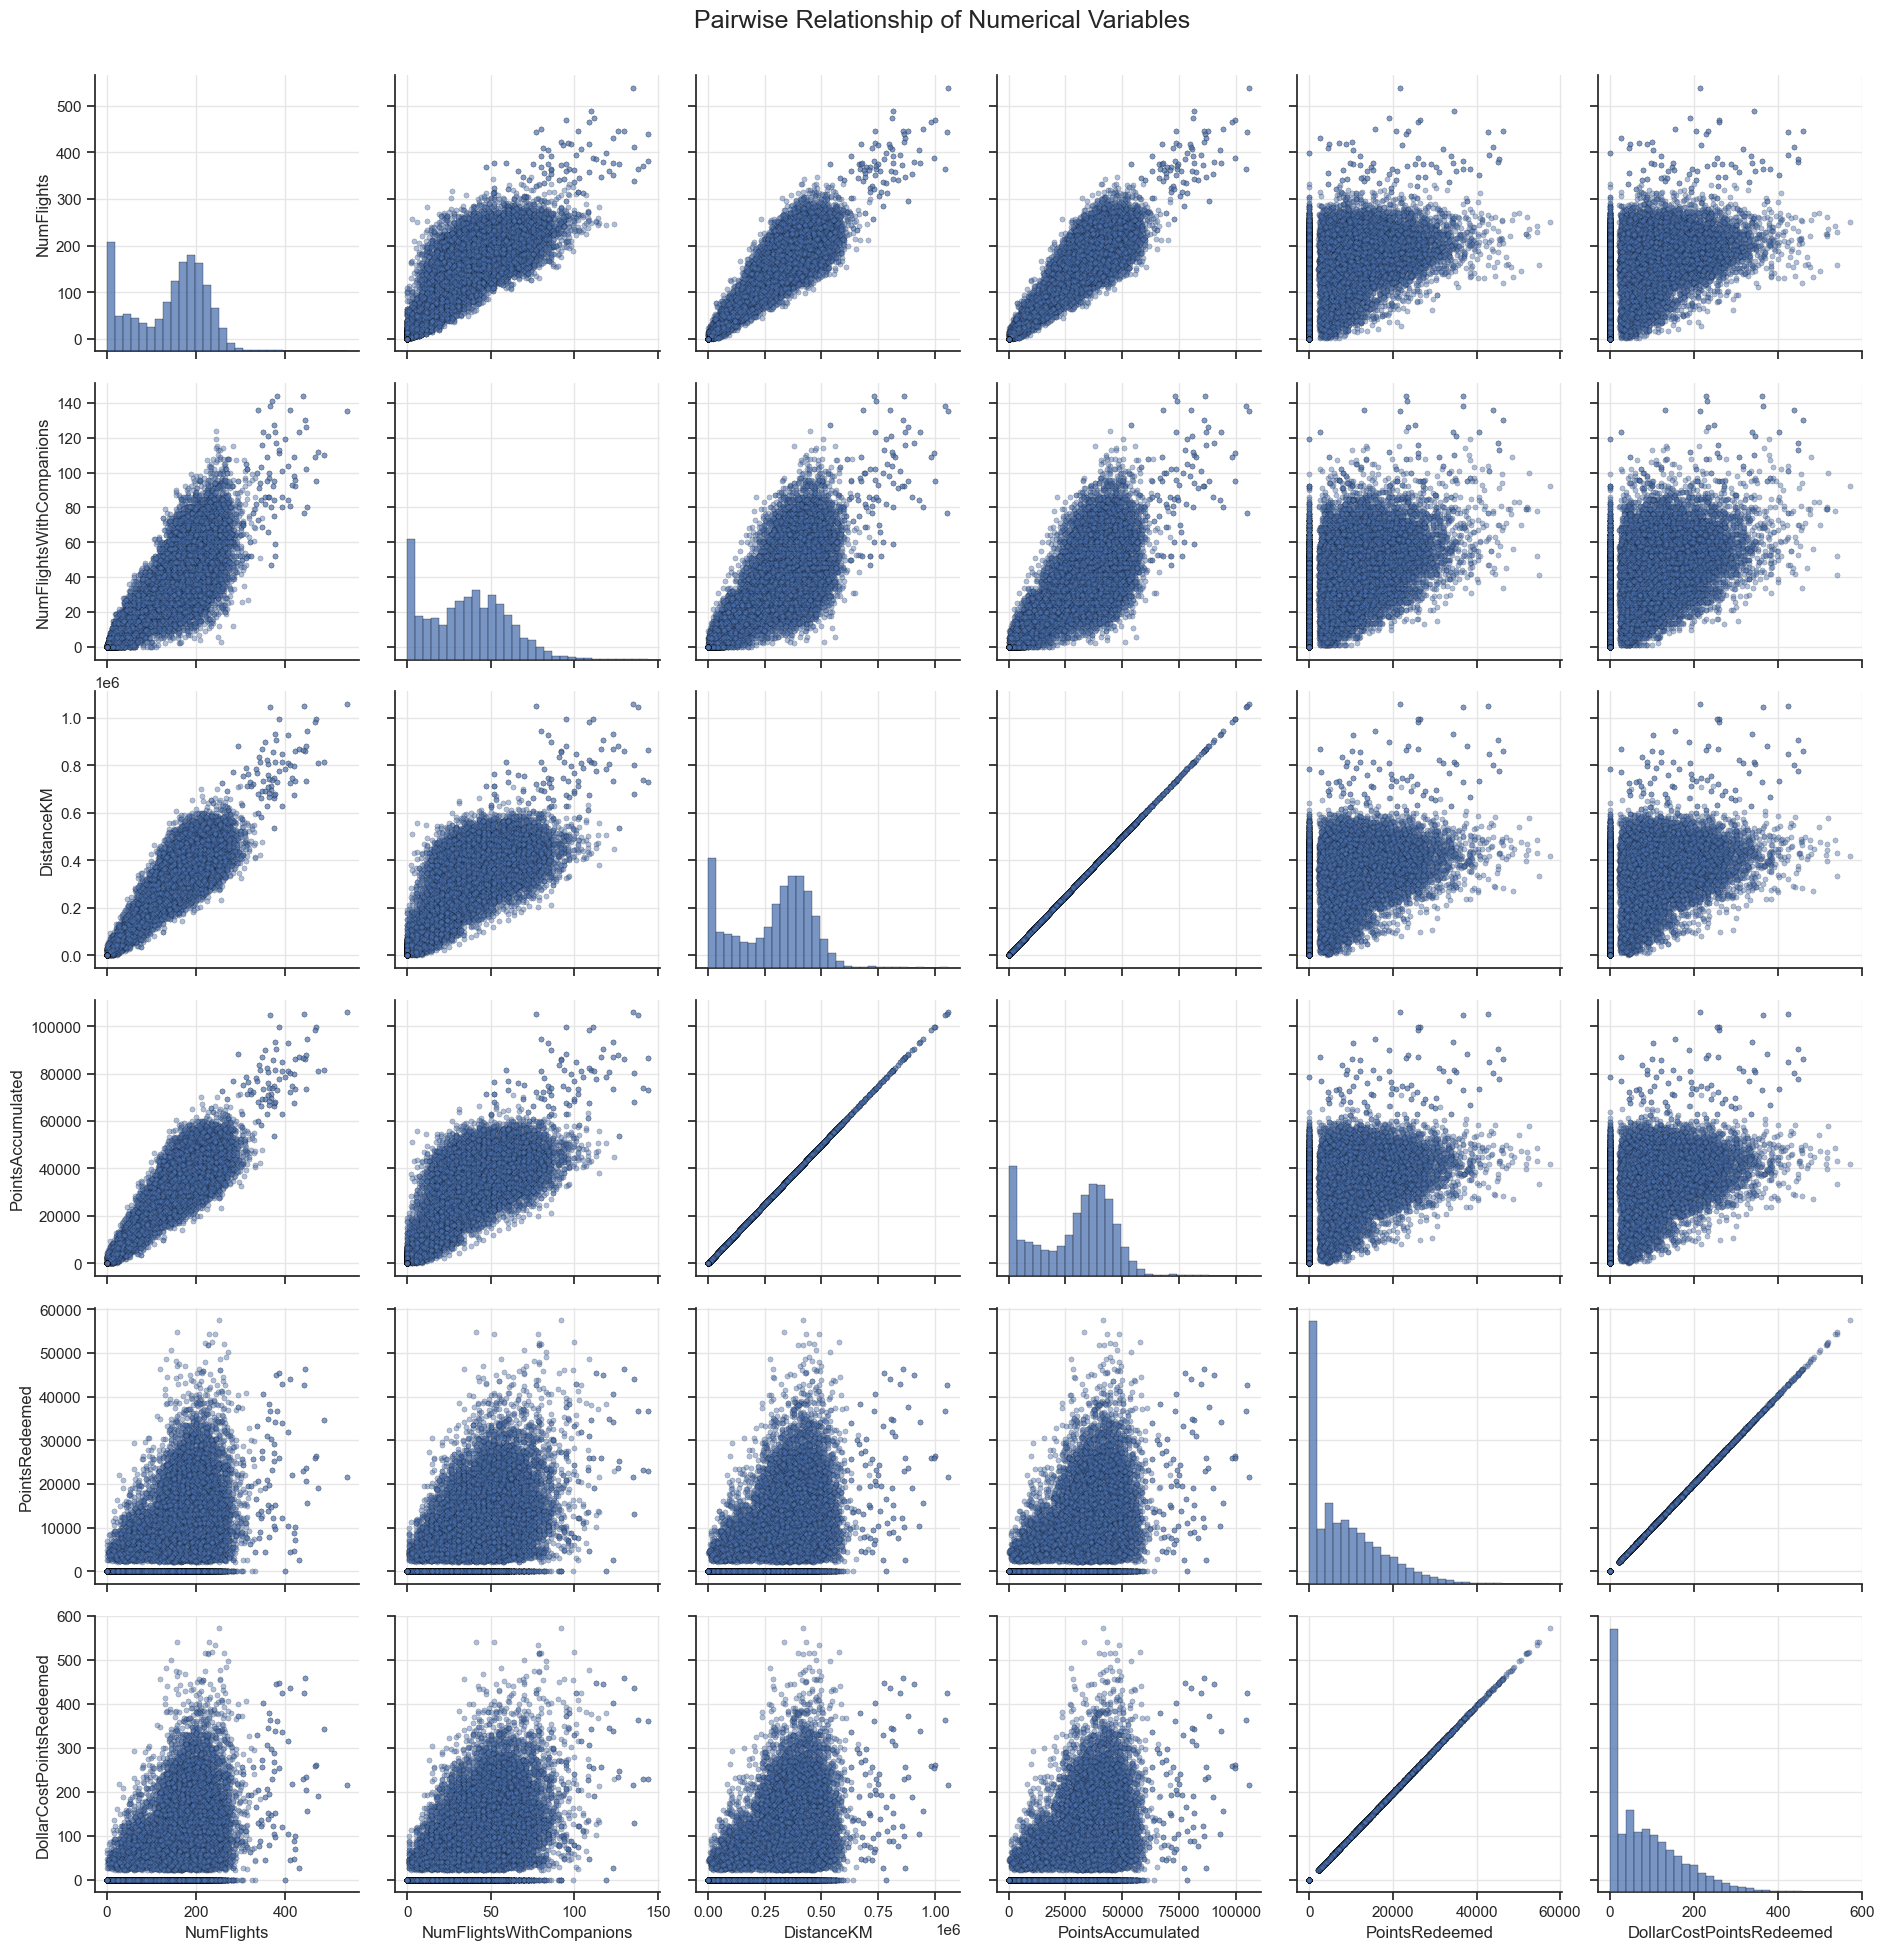

In [17]:
plot_pairwise_numeric(customers_detailed, new_cols)

### Correlation matrix:

#### Spearman:

Handles skewness and outliers better than Pearson:

In [18]:
def plot_corr_heatmap(df, metric_features):
    
    fig = plt.figure(figsize=(10, 8)) 
    corr = df[metric_features].corr(method="spearman")
    sns.heatmap(data=corr, annot=True, )

    plt.show()

### Graphical interpretation:

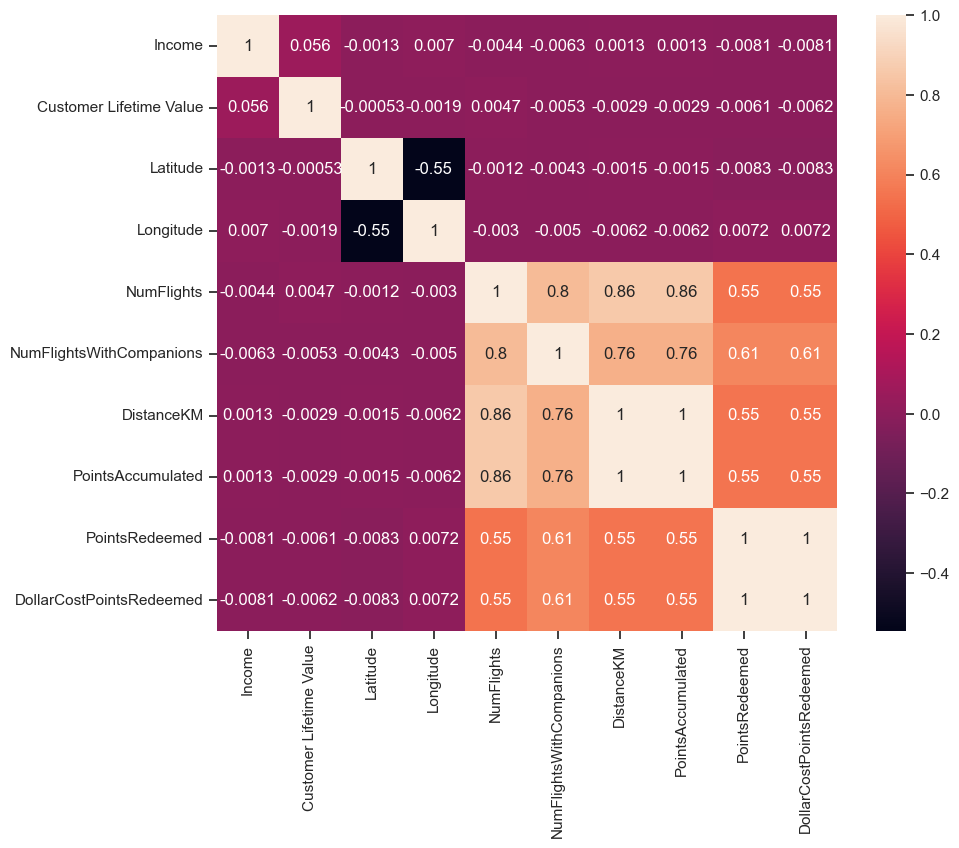

In [19]:
plot_corr_heatmap(customers_detailed, metric_features)

### Categorical x Categorical features:

In [20]:
def plot_stacked_bars_grid(
    df,
    features,                    
    stack_by="IsCancelled",      
    ncols=2,
    top_n=12,                    
    normalize=True,             
    figsize_per_row=(12, 4),
    rotate_xticks=30
):
    # figure grid
    n = len(features)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1]*nrows))
    axes = np.atleast_1d(axes).ravel()

    # stack order - sorted by frequency
    stack_levels = df[stack_by].astype("string").value_counts(dropna=False).index.tolist()

    for i, col in enumerate(features):
        ax = axes[i]
        s = df[col].astype("string").str.strip()

        # Keep top-N categories + 'Other'
        vc = s.value_counts(dropna=False)
        if top_n and len(vc) > top_n:
            top_vals = set(vc.head(top_n).index)
            s = s.where(s.isin(top_vals), "Other")

        # crosstab
        ct = pd.crosstab(s, df[stack_by].astype("string"), dropna=False).reindex(columns=stack_levels, fill_value=0)
        ct = ct.sort_values(ct.columns.tolist(), ascending=False)

        # normalize to percentages:
        if normalize:
            pct = ct.div(ct.sum(axis=1), axis=0).fillna(0) * 100
            plot_df = pct
            ylabel = "Percent"
        else:
            plot_df = ct
            ylabel = "Count"

        # plot stacked bars
        bottoms = np.zeros(len(plot_df))
        x = np.arange(len(plot_df.index))
        for lvl in plot_df.columns:
            vals = plot_df[lvl].values
            ax.bar(x, vals, bottom=bottoms, label=str(lvl))
            bottoms += vals

        # labels:
        ax.set_title(f"{col} × {stack_by}")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df.index, rotation=rotate_xticks, ha="right")
        ax.grid(axis="y", alpha=0.25)

        # annotate percentages on the bars:
        if normalize:
            for xi in x:
                y0 = 0
                for lvl in plot_df.columns:
                    v = plot_df.loc[plot_df.index[xi], lvl]
                    if v >= 5:  
                        ax.text(xi, y0 + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=8)
                    y0 += v

    # legend:
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=stack_by, loc="upper center", ncol=min(len(labels), 5), frameon=False, bbox_to_anchor=(0.5, 1.02))

    # remove unused axes:
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



### Graphical interpretation:

### Numerical x Categorical features:

In [21]:
def plot_hist_by_categories(
    df,
    numeric_col: str,
    cat_cols: list[str],
    ncols: int = 2,
    bins: int | str = 40,         
    stat: str = "density",        
    element: str = "step",         
    alpha: float = 0.35,
    figsize_per_row: tuple = (12, 4),
    title_prefix: str = "Histogram of",
):

    sns.set_theme(style="ticks")

    # Compute common bins from the numeric column (ignores NaNs)
    x = df[numeric_col].astype(float)
    bin_edges = np.histogram_bin_edges(x[np.isfinite(x)], bins=bins)

    n = len(cat_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, cat in enumerate(cat_cols):
        ax = axes[i]
        sns.histplot(
            data=df.dropna(subset=[cat]),
            x=numeric_col,
            hue=cat,
            bins=bin_edges,
            element=element,
            stat=stat,
            common_bins=True,
            alpha=alpha,
            ax=ax,
        )
        ax.set_title(f"{title_prefix} {numeric_col} by {cat}")
        ax.grid(alpha=0.25)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    plt.show()


### Graphical interpretation:

## Geographical Analysis:

## Postal code with feature from customers database:

## Graphical interpretation:

## City with feature from customers database:

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_37022/4037866768.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


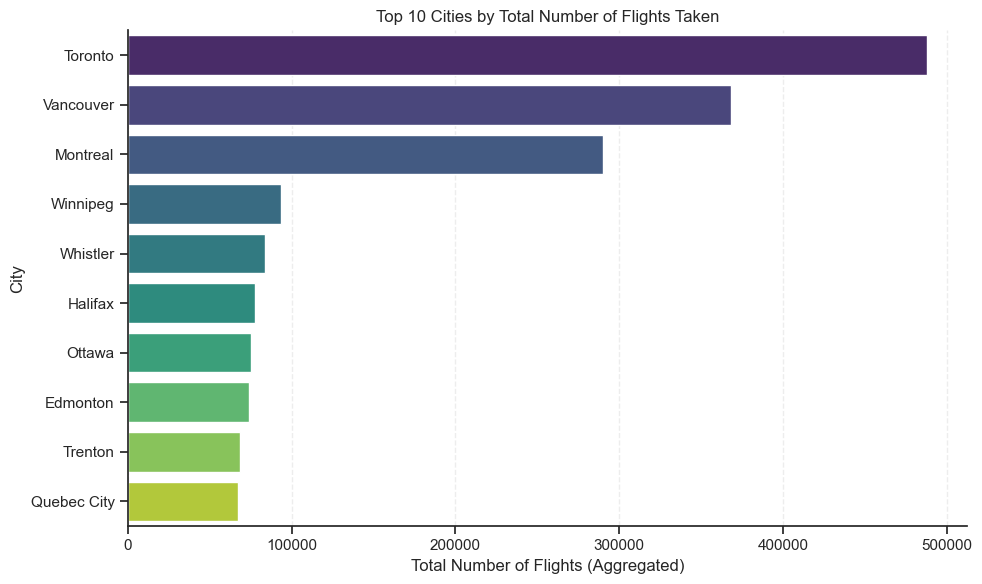

In [22]:
city_flights = customers_detailed.groupby('City')['NumFlights'].sum().reset_index()

# Rename the aggregated column for clarity
city_flights.columns = ['City', 'NumFlights_by_City']

# Sort the data and select the top 10 cities
top_10_cities = city_flights.sort_values(by='NumFlights_by_City', ascending=False).head(10)

# --- 2. CREATE BAR CHART ---

plt.figure(figsize=(10, 6))
# Use the aggregated column for the plot
sns.barplot(
    x='NumFlights_by_City',
    y='City',
    data=top_10_cities,
    palette='viridis' # Use a distinct color palette
)

plt.title('Top 10 Cities by Total Number of Flights Taken')
plt.xlabel('Total Number of Flights (Aggregated)')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Graphical interpretation:

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_37022/1130989520.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


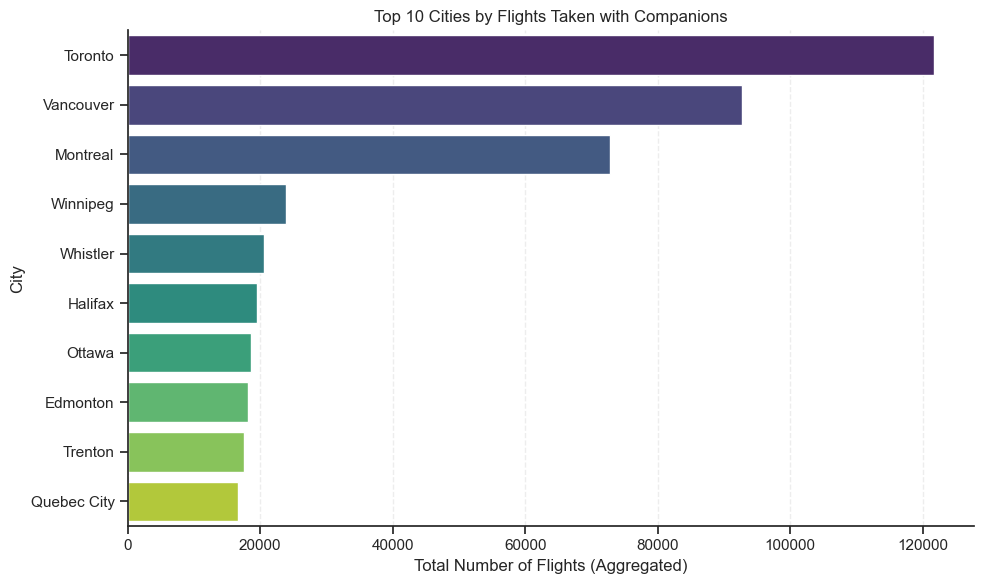

In [23]:
city_flights = customers_detailed.groupby('City')['NumFlightsWithCompanions'].sum().reset_index()

# Rename the aggregated column for clarity
city_flights.columns = ['City', 'NumFlightsWithCompanions_by_City']

# Sort the data and select the top 10 cities
top_10_cities = city_flights.sort_values(by='NumFlightsWithCompanions_by_City', ascending=False).head(10)

# --- 2. CREATE BAR CHART ---

plt.figure(figsize=(10, 6))
# Use the aggregated column for the plot
sns.barplot(
    x='NumFlightsWithCompanions_by_City',
    y='City',
    data=top_10_cities,
    palette='viridis' # Use a distinct color palette
)

plt.title('Top 10 Cities by Flights Taken with Companions')
plt.xlabel('Total Number of Flights (Aggregated)')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

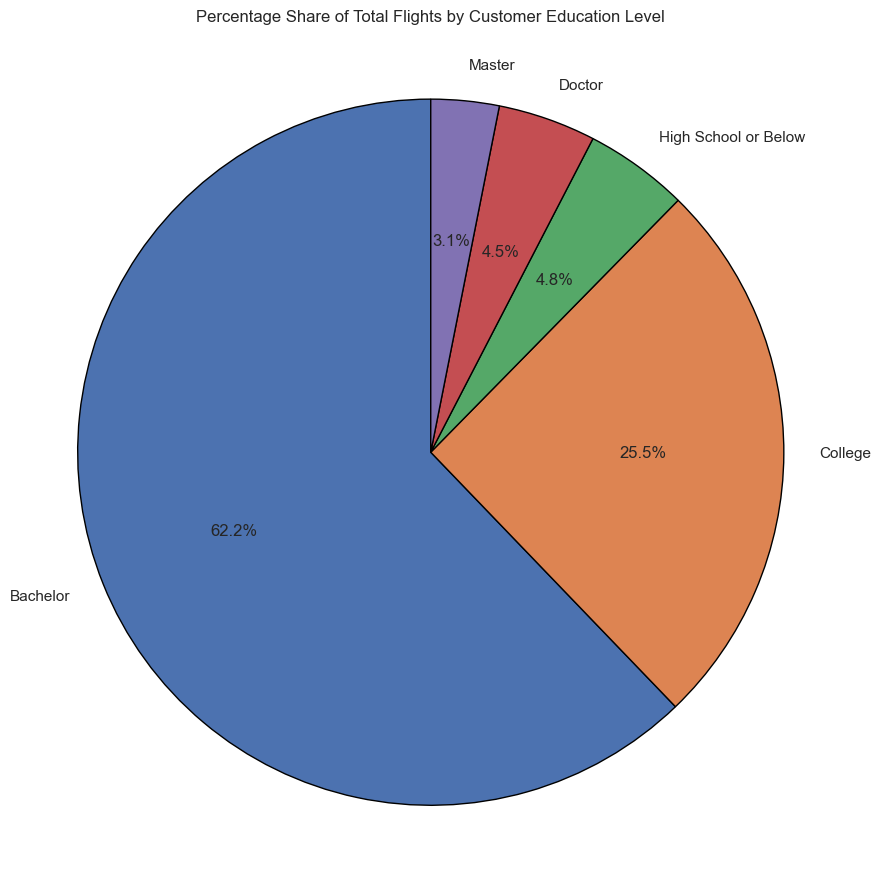

In [24]:
# --- 1. AGGREGATE DATA BY EDUCATION ---

# Group by Education and sum the NumFlights column
education_flights = customers_detailed.groupby('Education')['NumFlights'].sum().reset_index()

# Rename the aggregated column for clarity
education_flights.columns = ['Education', 'NumFlights_by_Education']

# Sort the data by flight volume descending
education_flights = education_flights.sort_values(by='NumFlights_by_Education', ascending=False)

# --- 2. CREATE BAR CHART ---
sizes = education_flights['NumFlights_by_Education']
labels = education_flights['Education']

# --- 2. CREATE PIE CHART ---

plt.figure(figsize=(9, 9))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',       # Display percentage format (e.g., 25.5%)
    startangle=90,           # Start the largest slice at the top
    wedgeprops={'edgecolor': 'black'} # Add a black border to slices
)

plt.title('Percentage Share of Total Flights by Customer Education Level')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## longitude and latitude with features customers database:

In [25]:
def assign_home_region(row):
    """Assigns a mock region based on latitude/longitude for Canadian segmentation."""
    lat = row['Latitude']
    lon = row['Longitude']

    # Mock region logic based on Canadian geography
    # 1. Eastern Region (Toronto, Montreal area)
    if lat >= 43 and lat < 50 and lon > -85 and lon < -65:
        return 'East_Canada_Major'
    # 2. Western Region (Vancouver, Calgary area)
    elif lat >= 48 and lat < 55 and lon < -110 and lon > -128:
        return 'West_Coast_Hubs'
    # 3. Central/Prairie Region (Winnipeg, Saskatoon area)
    elif lat >= 50 and lat < 60 and lon >= -110 and lon <= -90:
        return 'Central_Prairies'
    else:
        return 'Far_North_or_Other'

In [26]:
customers_detailed['Home_Region'] = customers_detailed.apply(assign_home_region, axis=1)
print("'Home_Region' column added with Canadian logic")

'Home_Region' column added with Canadian logic


--- 3. Generating Geospatial Visualization ---
16921


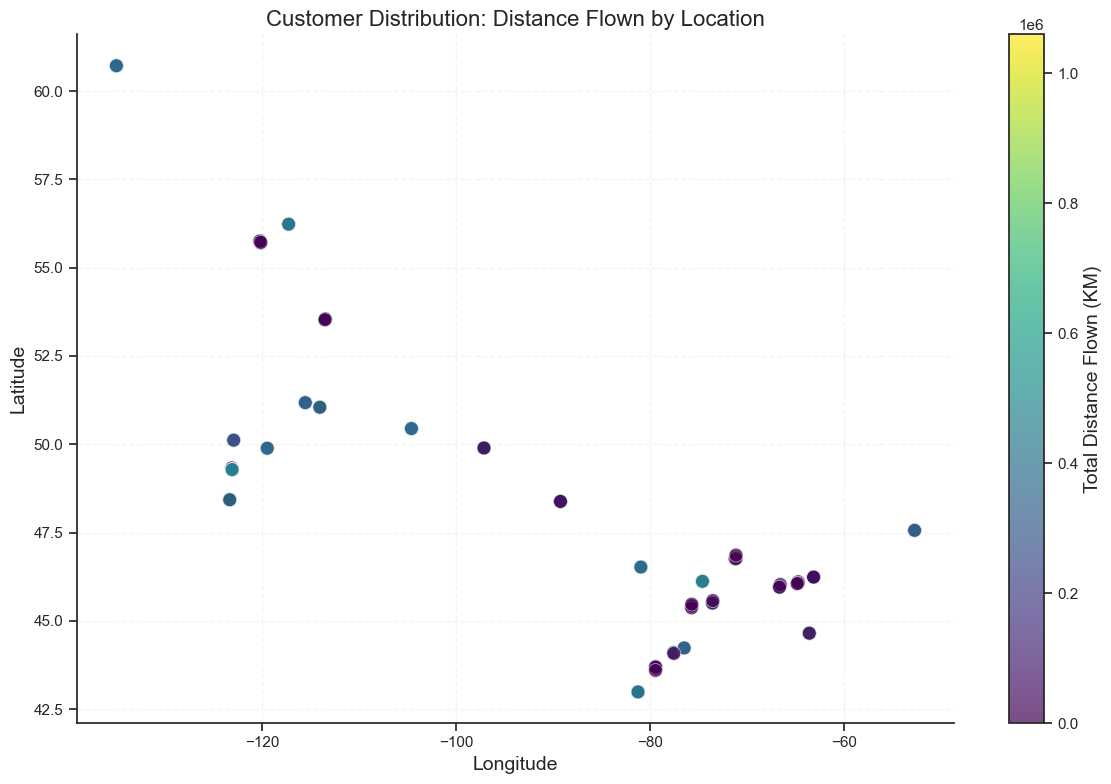

In [27]:
# --- 3. GRAPHICAL ANALYSIS 1: GEOSPATIAL SCATTER PLOT ---
# Visualize all customer locations, coloring the points by Total Distance Flown.
print("--- 3. Generating Geospatial Visualization ---")
plt.figure(figsize=(12, 8))

# Scatter plot: Longitude on X-axis, Latitude on Y-axis
# c=DistanceKM colors the points based on distance
# s=100 sets the size of the points
# cmap='viridis' is a color map suitable for continuous data
print(len(customers_detailed['Longitude']))
scatter = plt.scatter(
    customers_detailed['Longitude'],
    customers_detailed['Latitude'],
    c=customers_detailed['DistanceKM'],
    cmap='viridis',
    s=100,
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)


# Add a color bar to explain the colors
cbar = plt.colorbar(scatter)
cbar.set_label('Total Distance Flown (KM)', fontsize=14)
plt.xlabel("Longitude", fontsize=14)
plt.ylabel("Latitude", fontsize=14)
plt.title("Customer Distribution: Distance Flown by Location", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show() # Display the geospatial scatter plot


In [28]:
# --- GRAPHICAL ANALYSIS 2: REGIONAL AGGREGATION CHART ---
# Group the data by the new 'Home_Region' and calculate the average flights.
print("Performing Regional Aggregation and Visualization")
regional_summary = customers_detailed.groupby('Home_Region').agg(
    Avg_Flights=('NumFlights', 'mean'),
    Total_Points=('PointsAccumulated', 'sum'),
    Customer_Count=('Loyalty#', 'count')
).reset_index()

print(regional_summary)


Performing Regional Aggregation and Visualization
          Home_Region  Avg_Flights  Total_Points  Customer_Count
0    Central_Prairies   140.160194  1.172645e+07             412
1   East_Canada_Major   142.377036  2.544942e+08            8779
2  Far_North_or_Other   141.357667  8.211972e+07            2863
3     West_Coast_Hubs   142.734950  1.419448e+08            4867


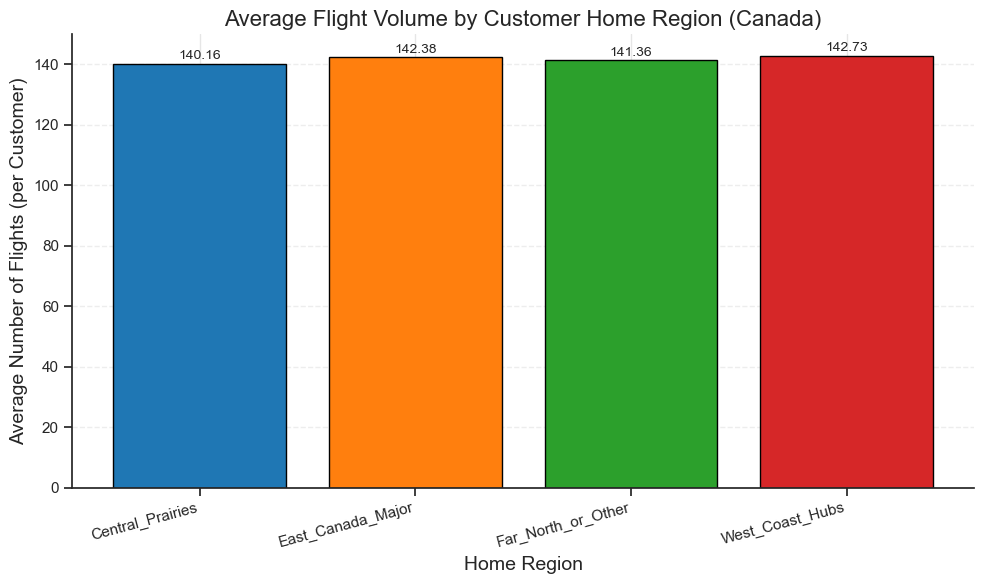

In [29]:

# Visualize the average number of flights per region
plt.figure(figsize=(10, 6))
bars = plt.bar(
    regional_summary['Home_Region'],
    regional_summary['Avg_Flights'],
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
    edgecolor='black'
)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
             round(yval, 2), ha='center', va='bottom', fontsize=10)

plt.xlabel("Home Region", fontsize=14)
plt.ylabel("Average Number of Flights (per Customer)", fontsize=14)
plt.title("Average Flight Volume by Customer Home Region (Canada)", fontsize=16)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() # Display the regional bar chart


## Graphical interpretation:

In [30]:
! conda install -y geopandas

Channels:
 - defaults
 - conda-forge
Platform: osx-64
Solving environment: done

# All requested packages already installed.



In [31]:
import unicodedata
import geopandas as gpd

In [39]:
def normalize_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .map(lambda t: "".join(
             c for c in unicodedata.normalize("NFKD", t) if not unicodedata.combining(c)
         ))
         .str.strip()
         .str.lower()
    )

def choropleth_canada_gadm_fast(
    metric: str = "count",
    value: str | None = None,
    condition: pd.Series | None = None,
    customers_key: str = "Province or State",
    admin1_dir: str = "gadm41_CAN_shp",
    cmap: str = "OrRd",
    title: str | None = None,
    figsize: tuple = (10, 7),
):

    gdf = gpd.read_file(f"{admin1_dir}/gadm41_CAN_1.shp")
    name_col = "NAME_1" if "NAME_1" in gdf.columns else next(c for c in gdf.columns if "NAME" in c.upper())


    ALIASES = {
        "newfoundland": "newfoundland and labrador"
    }


    key_left  = normalize_series(customers_detailed[customers_key]).replace(ALIASES)
    key_right = normalize_series(gdf[name_col])


    if metric == "count":
        agg = key_left.to_frame("k").groupby("k").size().rename("metric").reset_index()
    elif metric in {"median", "mean", "p95"}:
        if value is None: raise ValueError("`value` é obrigatório para median/mean/p95.")
        vals = pd.to_numeric(customers_detailed[value], errors="coerce")
        tmp = pd.DataFrame({"k": key_left, "v": vals})
        if metric == "median":
            agg = tmp.groupby("k")["v"].median().rename("metric").reset_index()
        elif metric == "mean":
            agg = tmp.groupby("k")["v"].mean().rename("metric").reset_index()
        else:
            agg = tmp.groupby("k")["v"].quantile(0.95).rename("metric").reset_index()
    elif metric == "share":
        if condition is None: raise ValueError("`condition` booleana é obrigatória para share.")
        tmp = pd.DataFrame({"k": key_left, "f": condition.astype(float)})
        agg = tmp.groupby("k")["f"].mean().rename("metric").reset_index()
    else:
        raise ValueError("metric deve ser 'count','median','mean','p95' ou 'share'.")

    gdf_merged = gdf.merge(agg, how="left", left_on=key_right, right_on="k")

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    gdf_merged.plot(
        column="metric", cmap=cmap, linewidth=0.6, edgecolor="white",
        legend=True, ax=ax,
        missing_kwds={"color": "#eeeeee", "hatch": "///", "label": "No data"}
    )
    ax.set_axis_off()
    if title is None:
        title = ("Customers by province/territory" if metric=="count"
                 else "Share by province/territory" if metric=="share"
                 else f"{metric.capitalize()} of {value} by province/territory")
    ax.set_title(f"{title} (Canada, GADM L1)", fontsize=12)
    plt.tight_layout()
    plt.show()

    unmatched = sorted(set(agg["k"]) - set(key_right.unique()))
    if unmatched:
        print("Unmatched (post-normalization) province names from customers_db:", unmatched)


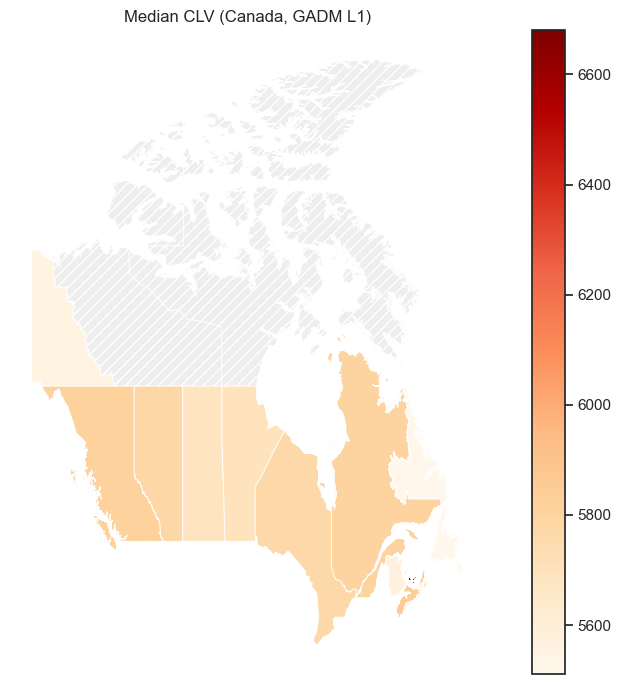

In [40]:
choropleth_canada_gadm_fast(metric="median", value="Customer Lifetime Value", title="Median CLV")

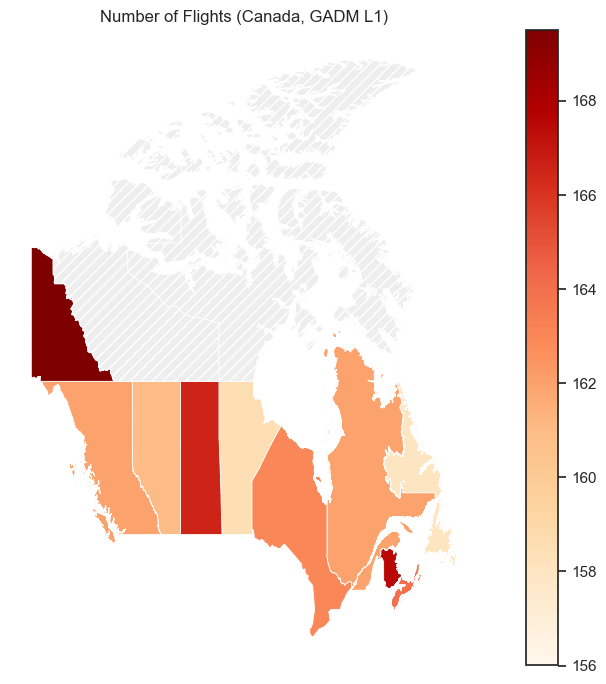

In [34]:
choropleth_canada_gadm_fast(metric="median", value="NumFlights", title="Number of Flights")

### Conclusion
The graph reveals that the airline's most frequent individual flyers are not primarily concentrated in the typical high-population hubs of Toronto or Montreal (Ontario/Quebec), but are heavily clustered on the West Coast (BC) and in Saskatchewan and Newfoundland.

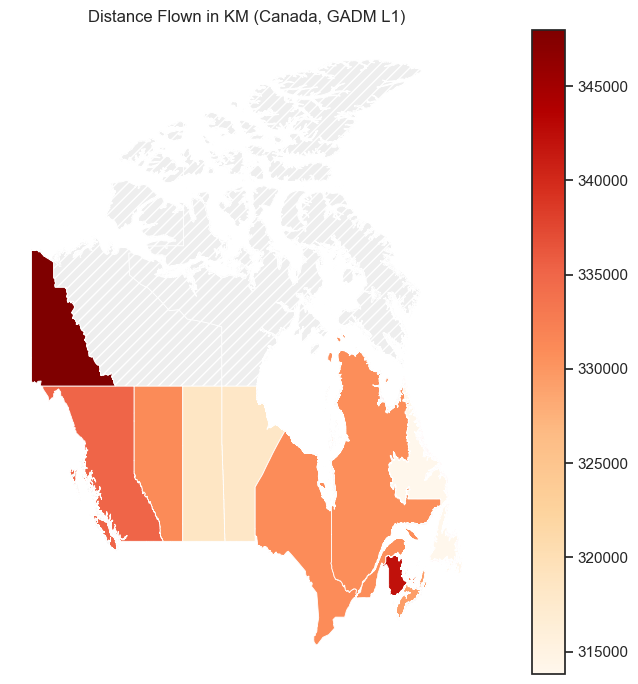

In [35]:
choropleth_canada_gadm_fast(metric="median", value="DistanceKM", title="Distance Flown in KM")

### Conclusion
British Columbia (BC) is colored the deepest red, indicating that the average customer in BC flies the highest total distance (in the $340,000$ to $345,000$ KM range).

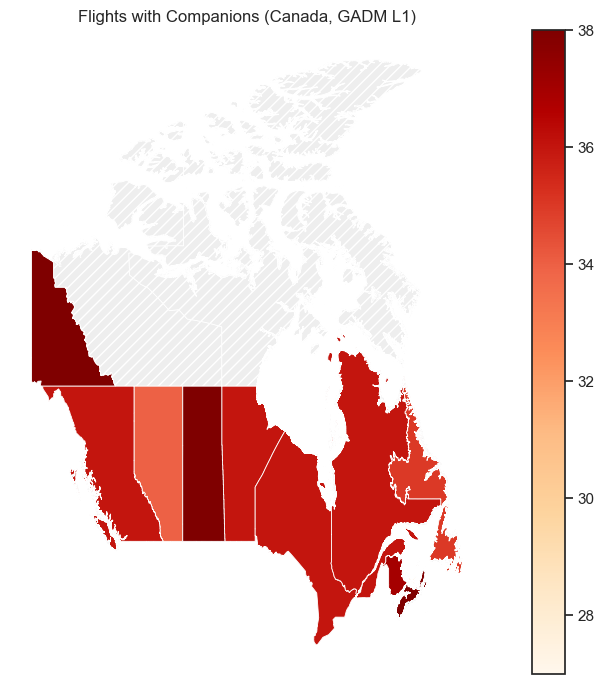

In [36]:
choropleth_canada_gadm_fast(metric="median", value="NumFlightsWithCompanions", title="Flights with Companions")

### Conclusion
Flights with Companions shows that Quebec and the Atlantic Provinces have the highest average number of companion flights, indicating they are the primary family and leisure travel markets. In contrast, the Prairie region of Manitoba shows the lowest rate of companion flights, suggesting a dominance of solo/business travel. This difference is key for segmenting marketing efforts.

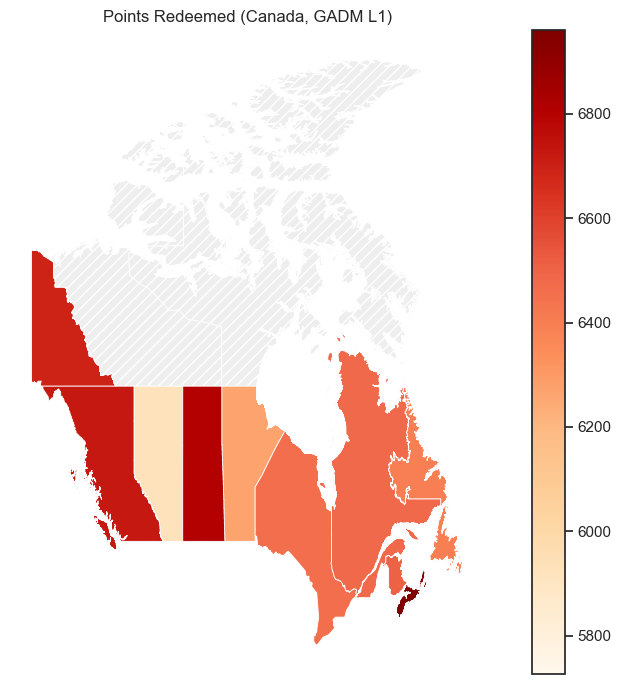

In [37]:
choropleth_canada_gadm_fast(metric="median", value="PointsRedeemed", title="Points Redeemed")

### Conclusion
Points Redeemed (Canada, GADM L1), reveals where customers are actively utilizing their accumulated loyalty points, showing that redemption activity is concentrated on the West Coast (BC) and in Alberta and Saskatchewan. In contrast, the high-population centers of Ontario and Quebec show lower per-customer redemption rates, indicating a potential pool of unspent points (a large financial liability) that the airline needs to encourage customers to use.

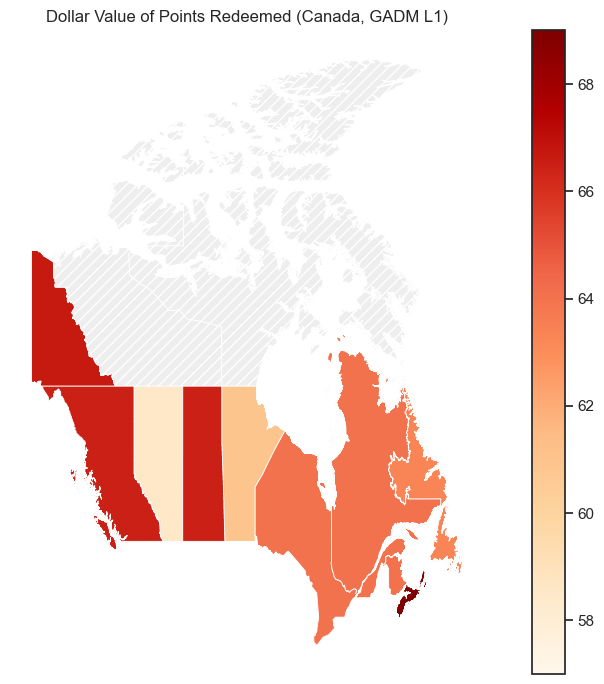

In [38]:
choropleth_canada_gadm_fast(metric="median", value="DollarCostPointsRedeemed", title="Dollar Value of Points Redeemed")

### Conclusion
Dollar Value of Points Redeemed (Canada, GADM L1), reinforces the previous loyalty conclusion: the highest dollar value of redemptions per customer occurs on the West Coast (BC) and in Newfoundland, suggesting these customers utilize their points for higher-value rewards like premium seats or long-haul flights. The central Prairie provinces and high-population centers like Ontario and Quebec show lower dollar value redemption, indicating their customers either redeem points less often or use them for lower-value transactions.